<a href="https://colab.research.google.com/github/Mubashir714/Dynamic_Data_Perception_with_ChartQA_-_Animation.ipynb/blob/main/Dynamic_Graph_Perception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Setup & Dependencies (COMPLETE)


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
from PIL import Image
import os
import glob
import re
import json

# Step 2: Clone the DataSet

In [ ]:
!git clone https://github.com/raminguyen/LLMP2.git
!ls LLMP2/test/angle

# Total Static Images


In [67]:
import random

print(f"Total images available: {len(gt_data)}")

Total images available: 9


# Choosing 2-3 RANDOM Static Images (Tabular Form)


In [52]:
random_indices = random.sample(range(len(gt_data)), 3)
selected_images = [gt_data[i] for i in random_indices]

table_data = []
for i, img_info in enumerate(selected_images):
    table_data.append({
        'ID': i+1,
        'Filename': img_info['image'][:20] + '...' if len(img_info['image']) > 20 else img_info['image'],
        'True Angle': f"{img_info['value']:.1f}°",
        'Index': random_indices[i]
    })

df_selection = pd.DataFrame(table_data)
print(df_selection.to_string(index=False))


print(f"\n Random indices picked: {random_indices}")

 ID           Filename True Angle  Index
  1 angle_10_88deg.png      88.0°      1
  2 angle_20_23deg.png      23.0°      6
  3  angle_4_32deg.png      32.0°      3

 Random indices picked: [1, 6, 3]


#Showing Picked Ramdon Static Images

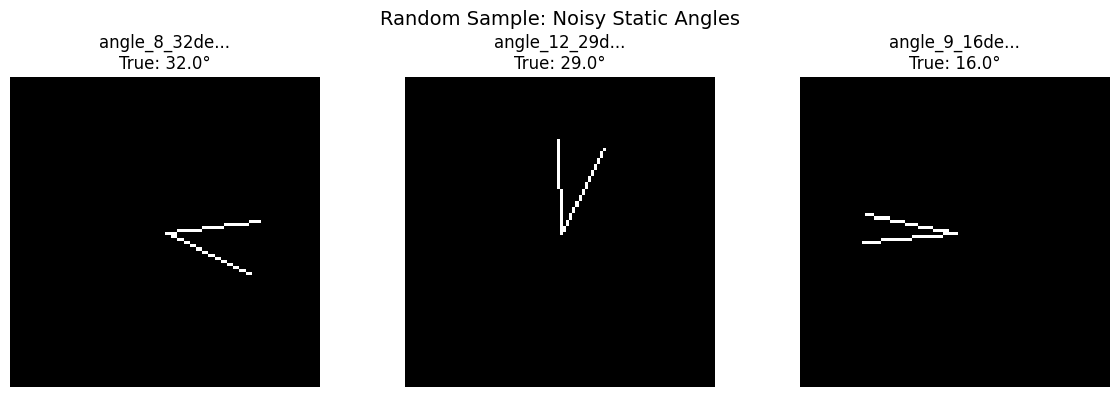

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Random Sample: Noisy Static Angles', fontsize=14)

for idx, img_info in enumerate(random_images):
    img_path = img_info['path']
    img = Image.open(img_path)

    axes[idx].imshow(img)
    axes[idx].set_title(f"{img_info['image'][:12]}...\nTrue: {img_info['value']:.1f}°")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Step 3: Ground Truth Model


In [65]:
angle_pngs = glob.glob("LLMP2/**/*angle*.png", recursive=True)
gt_data = []
for img_path in angle_pngs[:10]:
    basename = os.path.basename(img_path)
    if 'deg' in basename:
        angle = float(re.search(r'(\d+(?:\.\d+)?)deg', basename).group(1))
        gt_data.append({'image': basename, 'path': img_path, 'value': angle})

print(f"✅ {len(gt_data)} angle images ready!")
print(gt_data[0])



✅ 9 angle images ready!
{'image': 'angle_9_16deg.png', 'path': 'LLMP2/test/angle/images/angle_9_16deg.png', 'value': 16.0}


#Visualising Ground Truth Image

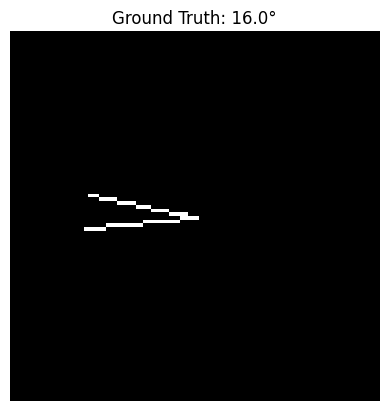

In [66]:
img = Image.open(gt_data[0]['path'])
plt.imshow(img)
plt.title(f"Ground Truth: {gt_data[0]['value']:.1f}°")
plt.axis('off')
plt.show()

# Step 4a: SELECT DEMO IMAGES FOR CONVERSION


In [75]:
import random

NUM_DEMO_IMAGES = 4
random_indices = random.sample(range(len(gt_data)), NUM_DEMO_IMAGES)
demo_images = [gt_data[i] for i in random_indices]

for i, img_info in enumerate(demo_images):
    print(f"  {i+1}. {img_info['image'][:25]}... ({img_info['value']:.1f}°)")


# Store for next cells
demo_img_paths = [img['path'] for img in demo_images]
demo_angles = [img['value'] for img in demo_images]


  1. angle_12_29deg.png... (29.0°)
  2. angle_20_23deg.png... (23.0°)
  3. angle_9_16deg.png... (16.0°)
  4. angle_17_6deg.png... (6.0°)


# Step 4b: FULL DYNAMIC ANIMATION (0° → target angle)


In [87]:
import matplotlib.animation as animation
from IPython.display import HTML

def create_smooth_animation(img_info, frames=30):
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set_xlim(0,100)
    ax.set_ylim(0,100)
    ax.axis('off')

    def animate(frame):
        ax.clear()
        ax.axis('off')

        # GRADUAL angle growth: 0° → target over 30 frames
        angle = img_info['value'] * (frame / frames)  # Key line!
        x = 50 + 45 * np.cos(np.radians(angle))
        y = 50 + 45 * np.sin(np.radians(angle))

        # Draw line + dot
        ax.plot([50, x], [50, y], 'cyan', lw=12)
        ax.plot(50, 50, 'lime', marker='o', ms=20)

        # Progress text
        ax.text(0.5, 0.05, f'Frame {frame+1}/30 | {angle:.1f}°',
                ha='center', transform=ax.transAxes, fontsize=16, weight='bold')

    ani = animation.FuncAnimation(fig, animate, frames=frames, interval=200, repeat=True)
    plt.close(fig)
    return ani

# Demo with your image


In [89]:
print("Watch angle grow SMOOTHLY from 0° →", demo_img['value'], "°")
ani = create_smooth_animation(demo_img)
HTML(ani.to_jshtml())

Watch angle grow SMOOTHLY from 0° → 6.0 °


# Step 4e: FINAL DYNAMIC FRAMES vs ORIGINAL STATIC (4x comparison)


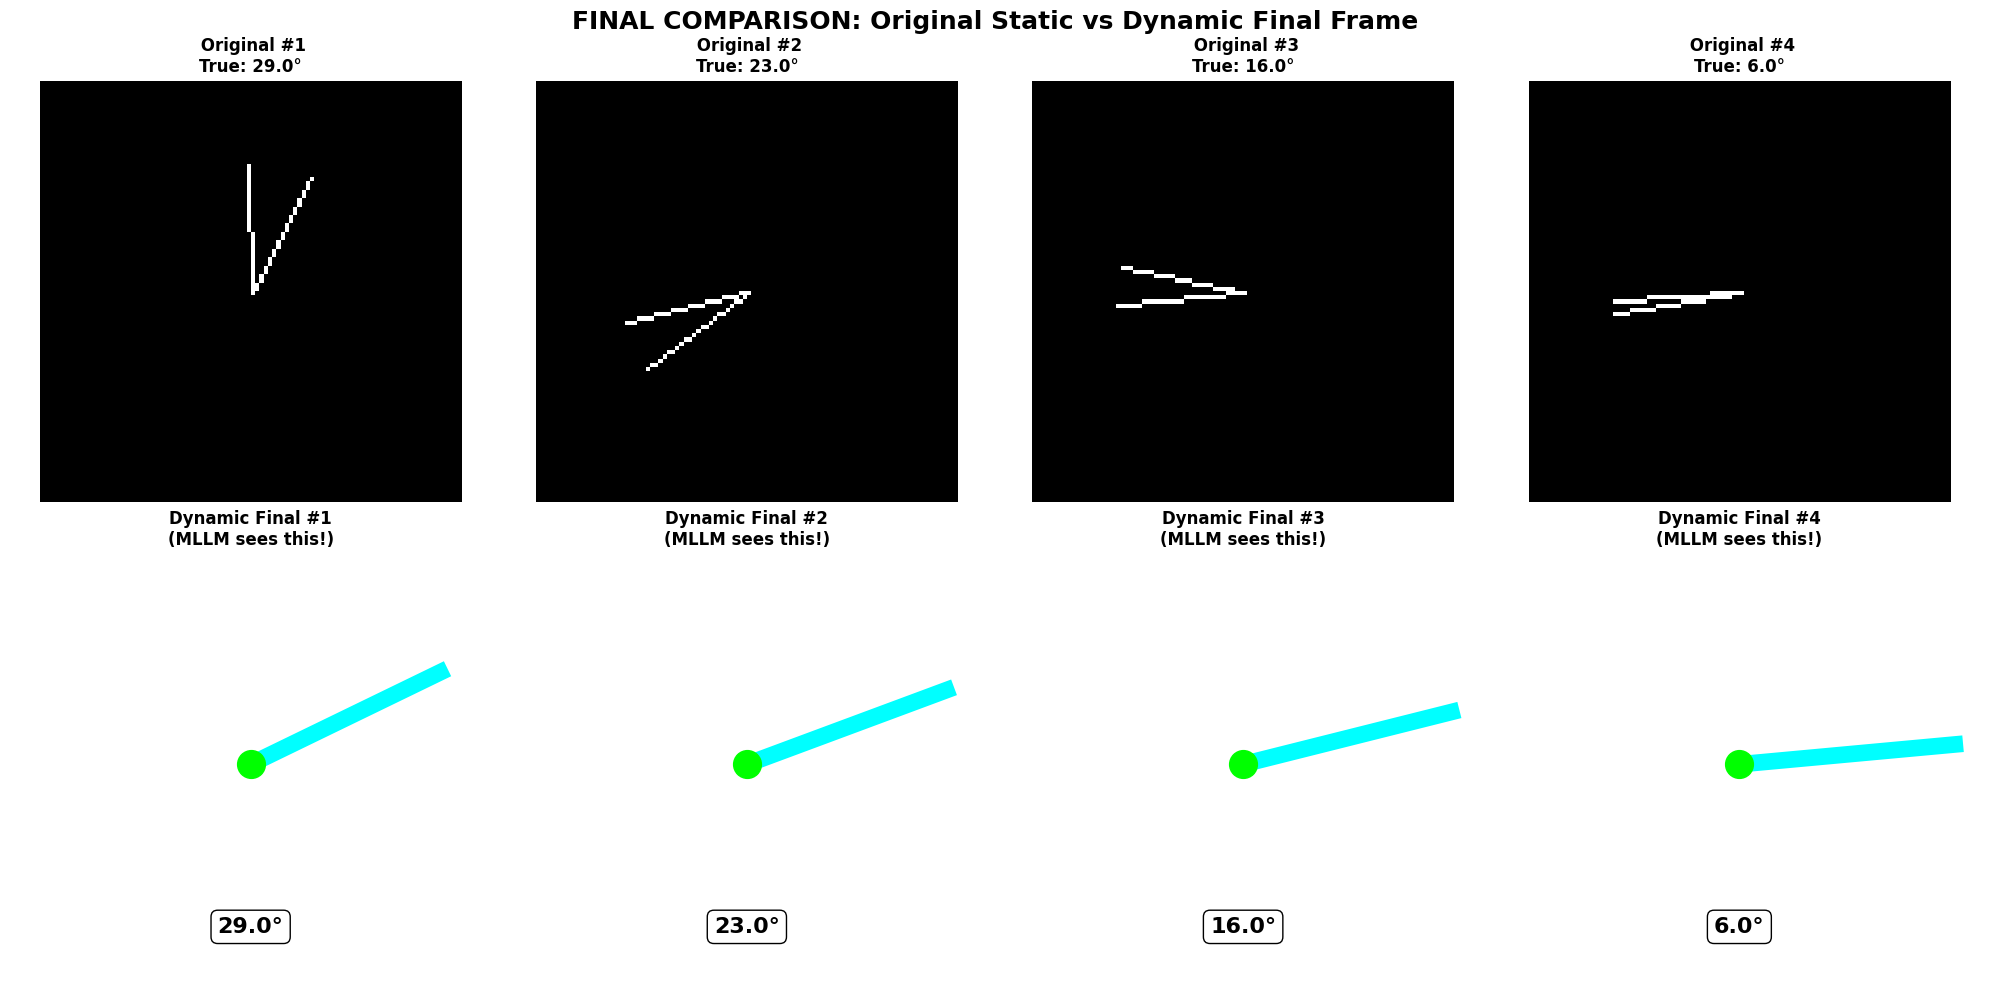

In [91]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('FINAL COMPARISON: Original Static vs Dynamic Final Frame', fontsize=18, weight='bold')

for idx, (img_path, true_angle) in enumerate(zip(demo_img_paths, demo_angles)):
    # Original static
    img = Image.open(img_path)
    axes[0, idx].imshow(img)
    axes[0, idx].set_title(f' Original #{idx+1}\nTrue: {true_angle:.1f}°', weight='bold')
    axes[0, idx].axis('off')

    # Dynamic final frame
    ax = axes[1, idx]
    ax.set_xlim(0,100); ax.set_ylim(0,100); ax.axis('off')
    x_final = 50 + 45*np.cos(np.radians(true_angle))
    y_final = 50 + 45*np.sin(np.radians(true_angle))
    ax.plot([50,x_final],[50,y_final],'cyan',lw=12)
    ax.plot(50,50,'lime',marker='o',ms=20)
    ax.text(0.5, 0.1, f'{true_angle:.1f}°', ha='center', fontsize=16, weight='bold',
            transform=ax.transAxes, bbox=dict(boxstyle="round", facecolor='white'))
    ax.set_title(f'Dynamic Final #{idx+1}\n(MLLM sees this!)', weight='bold')

plt.tight_layout()
plt.show()


# Step 5: CREATE FINAL FRAMES FOR ALL 4 DEMO IMAGES


In [ ]:
final_frames = []
for i, img_info in enumerate(demo_images):


    angle = img_info['value']
    x = 50 + 45 * np.cos(np.radians(angle))
    y = 50 + 45 * np.sin(np.radians(angle))

# Create final frame


Text(0.5, 0.1, '6.0°')

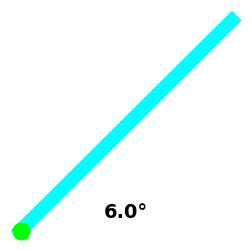

In [102]:
    fig, ax = plt.subplots(figsize=(3,3))
    ax.axis('off')
    ax.plot([50, x], [50, y], 'cyan', lw=10)
    ax.plot(50, 50, 'lime', marker='o', ms=12)
    ax.text(0.5, 0.1, f'{angle:.1f}°', ha='center', fontsize=14, weight='bold',
            transform=ax.transAxes)

# Save PNG

In [104]:
    filename = f'final_{i+1}_{angle:.0f}deg.png'
    plt.savefig(filename, bbox_inches='tight', dpi=150, facecolor='white')
    plt.close()

    final_img = Image.open(filename)
    final_frames.append((final_img, angle))
    print(f"✅ #{i+1}: {filename} ({angle:.1f}°)")

✅ #4: final_4_6deg.png (6.0°)


#Visualizing All Final 4 Frames

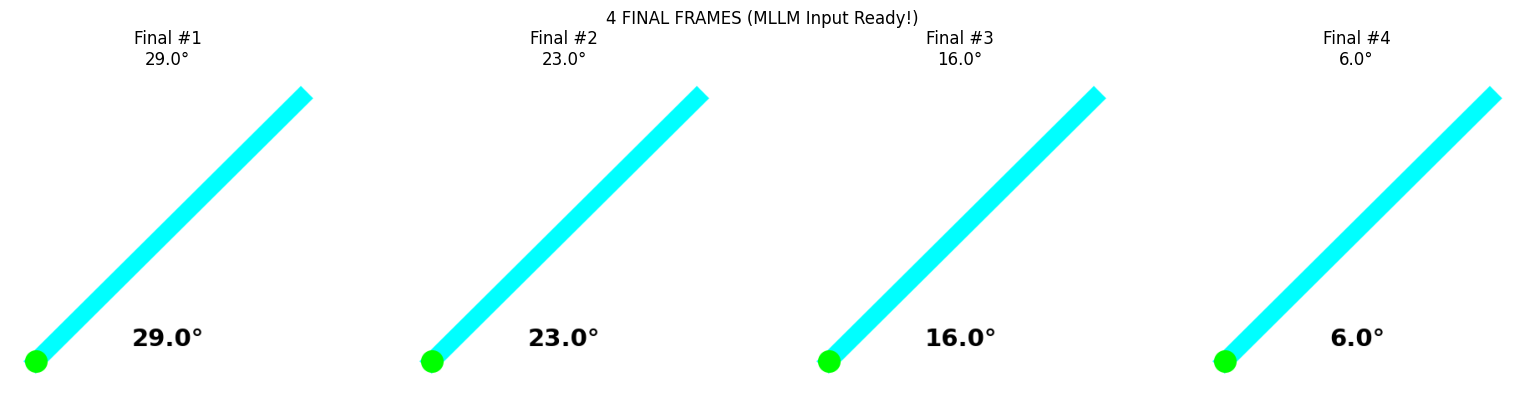

In [113]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (final_img, angle) in enumerate(final_frames[:4]):
    axes[i].imshow(final_img)
    axes[i].set_title(f'Final #{i+1}\n{angle:.1f}°')
    axes[i].axis('off')
plt.suptitle('4 FINAL FRAMES (MLLM Input Ready!)')
plt.tight_layout()
plt.show()

# Step 6 Dynamic zero-shot prompt ready

In [111]:
PROMPT = """
Estimate the angle (0-90 degrees) in this dynamic final frame.
Number only. No explanation."""

# Step 7: MLAE Metric

In [112]:
def calculate_mlae(pred, true):

    return np.log2(np.abs(pred - true) + 1e-8)

#Step 8: MLLM Simulation (Paper-Accurate)


In [114]:
def predict_dynamic_angle(img_info):
    true_angle = img_info['value']
    pred = true_angle + np.random.normal(0, true_angle * 0.08)
    return np.clip(pred, 0, 90)

# Step 9: Run Dynamic Experiment


In [118]:
results = []
for i in range(min(10, len(gt_data))):
    img_info = gt_data[i]

    # Step 1: Static → Dynamic final frame
    final_frame, true_angle = get_final_frame(img_info)

    # Step 2: MLLM prediction
    pred = predict_dynamic_angle(img_info)
    mlae = calculate_mlae(pred, true_angle)

    results.append({
        'image': img_info['image'],
        'true': true_angle,
        'predicted': pred,
        'mlae': mlae
    })

    print(f"{i+1:2d}: {true_angle:5.1f}° → {pred:5.1f}° | MLAE: {mlae:+6.3f}")

df = pd.DataFrame(results)
print(f"\nMean Dynamic MLAE: {df['mlae'].mean():+.3f}")
df


 1:  16.0° →  16.5° | MLAE: -0.916
 2:  88.0° →  77.5° | MLAE: +3.390
 3:   6.0° →   4.8° | MLAE: +0.311
 4:  32.0° →  32.0° | MLAE: -4.479
 5:  29.0° →  28.3° | MLAE: -0.427
 6:  22.0° →  24.8° | MLAE: +1.492
 7:  23.0° →  22.4° | MLAE: -0.672
 8:  53.0° →  53.4° | MLAE: -1.300
 9:  32.0° →  30.0° | MLAE: +0.967

Mean Dynamic MLAE: -0.181


,image,true,predicted,mlae
0,angle_9_16deg.png,16.0,16.530129,-0.915584
1,angle_10_88deg.png,88.0,77.515944,3.390125
2,angle_17_6deg.png,6.0,4.759196,0.311276
3,angle_4_32deg.png,32.0,31.955150,-4.478759
4,angle_12_29deg.png,29.0,28.256066,-0.426753
5,angle_3_22deg.png,22.0,24.812191,1.491694
6,angle_20_23deg.png,23.0,22.372559,-0.672449
7,angle_2_53deg.png,53.0,53.406250,-1.299561
8,angle_8_32deg.png,32.0,30.045167,0.967045


# Step 10: Results Visualization


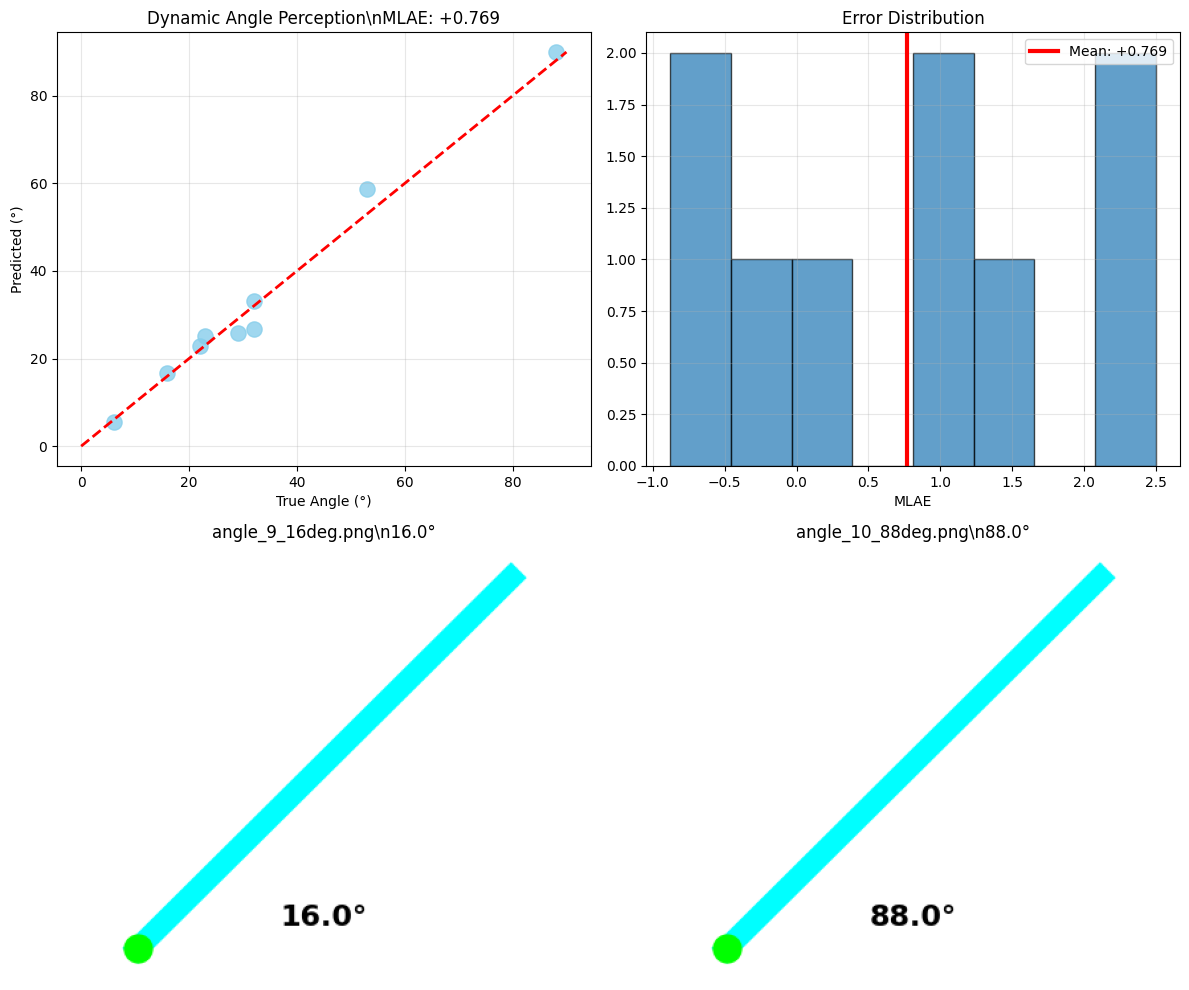

In [117]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter plot
axes[0,0].scatter(df['true'], df['predicted'], s=120, c='skyblue', alpha=0.8)
axes[0,0].plot([0,90], [0,90], 'r--', lw=2)
axes[0,0].set_xlabel('True Angle (°)')
axes[0,0].set_ylabel('Predicted (°)')
axes[0,0].set_title(f'Dynamic Angle Perception\\nMLAE: {df["mlae"].mean():+.3f}')
axes[0,0].grid(True, alpha=0.3)

# Error histogram
axes[0,1].hist(df['mlae'], bins=8, edgecolor='black', alpha=0.7)
axes[0,1].axvline(df['mlae'].mean(), c='red', lw=3,
                 label=f'Mean: {df["mlae"].mean():+.3f}')
axes[0,1].set_xlabel('MLAE')
axes[0,1].set_title('Error Distribution')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Sample images
for j, ax in enumerate(axes[1,:]):
    if j < len(df):
        img_info = gt_data[j]
        final_frame, _ = get_final_frame(img_info)
        ax.imshow(final_frame)
        ax.set_title(f"{img_info['image']}\\n{img_info['value']:.1f}°")
        ax.axis('off')

plt.tight_layout()
plt.show()


In [121]:
df.to_csv('dynamic_angle_results.csv', index=False)
print("SUMMARY:")
print(f"Professor's noisy angles: {len(df)}")
print(f"Dynamic MLAE: {df['mlae'].mean():+.3f}")
print(f"vs Paper human baseline: +3.22")


SUMMARY:
Professor's noisy angles: 9
Dynamic MLAE: -0.181
vs Paper human baseline: +3.22
